# **Improving Multi-Class Mental Health Text Classification with BERT: A Comparison of Model Optimization Techniques with a Focus on Minority Class Detection**

Mental Health issues are prevalent across the globe.

This project utilizes BERT models to classify multiple mental health classes from text data through Natural Language Processing and explores how hyperparameter choices, data augmentation, and model architectures impact model performance. Regarding the severity of mental health illnesses, accuracy within this task is crucial.

Ultimately, this project aims to build a better multi-class mental health classification model to enable proactive support and contribute to effective AI-driven mental health support.



### **Research Question:**
*How do the modeling strategies hyperparameter tuning, class-specific data augmentation, and domain-specific architecture compare in maximizing BERT’s performance in multi-class mental health text classification, with an emphasis on improving minority class detection?*

#**Stage 0: Baseline Modeling**

## **Data Loading and Cleaning:**

The dataset we will use is one from kaggle. The dataset is a collection of statements and a corresponding mental health status. This data is collected from public social media forums on Reddit and Twitter.

https://www.kaggle.com/datasets/szegeelim/mental-health/data

In [ ]:
import pandas as pd

df = pd.read_csv("Combined Data.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
# Check for NaNs in dataframe
print("Any NaNs?", df.isna().any().any())
print("Number of empty Statements:", (df["statement"].str.strip() == "").sum())
print(df[df.isna().any(axis=1)])

Any NaNs? True
Number of empty Statements: 0
      statement   status
293         NaN  Anxiety
572         NaN  Anxiety
595         NaN  Anxiety
1539        NaN   Normal
2448        NaN   Normal
...         ...      ...
52838       NaN  Anxiety
52870       NaN  Anxiety
52936       NaN  Anxiety
53010       NaN  Anxiety
53031       NaN  Anxiety

[362 rows x 2 columns]


Since we observed some missing values in the statements column, it is better to remove the rows with NaNs as training BERT on empty text will interfere with our results.

In [ ]:
# Data Cleaning
df = df.dropna(subset=["statement"])      # remove NaNs
print("Any NaNs?", df.isna().any().any())

df.head()

Any NaNs? False


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In order to be compatible with the tokenizer.encode_plus function later on when encoding our data for the pretrained BERT model, column names must be changed from "statement" and "status" to "text" and "label" respectively.

In [ ]:
df.rename(columns={"statement": "text", "status": "label"}, inplace=True)
df.head()

,text,label
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


## **Exploratory Data Analysis:**

What is the shape of the data? How many different conditions are represented by this dataset? How many samples do we have for each mental health condition?

In [ ]:
# View text length data
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
print(df["text_length"].describe())
df.drop(columns=["text_length"], inplace=True)

count    52681.000000
mean       113.158729
std        163.735305
min          1.000000
25%         15.000000
50%         62.000000
75%        148.000000
max       6300.000000
Name: text_length, dtype: float64


Observations:
* Average text length seems to be around 113 characters (shorter average text lengths are expected with social media text data); Most likely the optimal max_len lies around 128
* Maximum and minimum seem extremely far off, so most likely outliers

Maximum Sequence Length is 1 of the 3 hyperparameters that we will be experimenting with in this research project. Visualizing details about the various text lengths allows us to better understand the scope of our data and refine our hypotheses.

In [ ]:
# Data size and shape
print(len(df) , df.shape)

52681 (52681, 2)


<Axes: title={'center': 'Class Distribution'}, ylabel='count'>

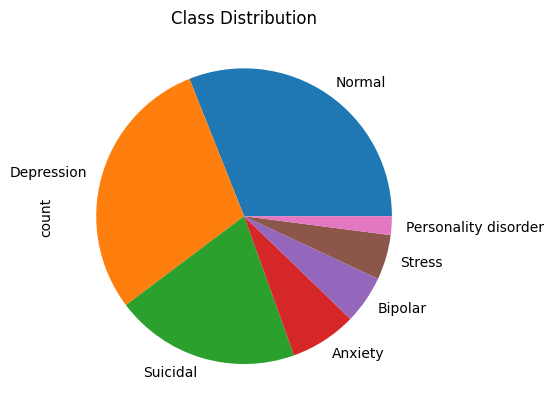

In [ ]:
df["label"].value_counts().plot(kind="pie", title="Class Distribution")    # Class distribution visualization

## **Skip the Data Loading and Cleaning:**

In [ ]:
df.to_csv("mental_health.csv", index=False)

from google.colab import files
files.download("mental_health.csv")
# DO NOT RUN THIS CELL UNLESS DOWNLOADING THE CLEANED CSV FILE

To import the **updated** csv file into the colab notebook, you must first go through all of the **"Data Loading and Cleaning"** section. **After that is done initially and the downloading cell right above is ran**, every time you open the notebook from there on, you can skip the data loading and cleaning.

In [ ]:
import pandas as pd
df = pd.read_csv("mental_health.csv")
df.head()

,text,label
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


## **Baseline Modeling:**


In [ ]:
# Split our data into 80% training data and 20% testing data.

from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

**BERT**

BERT (Bidirectional Encoder Representations from Transformers) is a powerful language model developed by Google. It belongs to a class of models called Transformers, which use a mechanism called self-attention to understand how words relate to each other in a sentence. This allows BERT to read entire sentences at once, hellping it capture deeper context.

Because transformers do not naturally know the order of words in a sentence, they use positional encoding enabling the models to understand sequence order and context.

This structure makes BERT especially effective for tasks such as text classification and sentiment analysis.

In [ ]:
!pip install transformers
!pip install transformers datasets --upgrade
!pip install nlpaug nltk

import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset, random_split
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
import random
import time

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.8/558.8 kB 37.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.33.4
    Uninstalling huggingface-hub-0.33.4:
      Successfully uninstalled huggingface-hub-0.33.4
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 15.2 MB/s eta 0:00:00


In [ ]:
# Setting up the device for GPU usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

"max_len" is our first experimental hyperparameter which we will use to control how many tokens BERT will read from each input text. "max_len" ranges from 1 to 512 tokens for the BERT model. Setting it too low can cut out important context while setting it too high will slow down training and increase the risk of overfitting our data. This is why it is important to find the optimal balance for our maximum sequence length: to maximize the accuracy of our model. Since BERT requires a fixed-length input, shorter texts are padded and longer texts are truncated to maintain consistency.

For baseline purposes, we will set "max_len" to 256, a general "max_len" value. Later on in the research project, we will explore how exploratory data analysis and hyperparameter configuration searches can allow us to choose a more accurate maximum sequence length.

In [ ]:
max_len = 256  # Maximum Length Hyperparameter #1

"lr", learning rate--our second experimental hyperparameter--controls how much the model’s weights are updated during each training step. A high learning rate can speed up convergence but risks overshooting the optimal solution. A low learning rate makes training more stable but can lead to very slow progress and overfitting the data.

"batch_size", our third and final experimental hyperparameter, defines how many samples are processed together before updating the model weights. Larger batch sizes give smoother, more reliable gradient estimates and faster training per epoch but may encourage overfitting and require more memory. Smaller batch sizes can help with generalization, but introduce more noise resulting in slower convergence times.

For these two influential hyperparameters, it is important to choose an optimal combination of batch size and learning rate. Using a large batch size with a low learning rate can make training unnecessarily slow and hinder progress, while a small batch size with a high learning rate can cause unstable updates and poor performance. Balancing these two hyperparameters helps achieve efficient and effective training.

For now, we will use general values of 0.0001 and 64 for our "lr" and "batch_size", respectively. Later on in the research project we will explore more accurate hyperparamter values and configurations.

In [ ]:
batch_size = 64  # Batch Size Hyperparameter #2
lr = 1e-4        # Learning Rate Hyperparameter #3

The BERT transformer encodes our data as embeddings, making our data understandable for the model and compatible with the BERT transformer architecture.

Once the input is embedded, the model uses feed-forward neural networks and self-attention to understand the relationships and context between words in a sentence.

In [ ]:
# Initialize label encoder
label_encoder = LabelEncoder()
label_encoder.fit(df['label'])

# Function to create tokenized DataLoaders
def create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size):
    """
    Tokenizes and encodes training and testing data, transforms labels, and creates PyTorch DataLoaders.

    Args:
        X_train {pd.Series or np.ndarray}: Training text samples.
        y_train {pd.Series or np.ndarray}: Corresponding labels for training data.
        X_test {pd.Series or np.ndarray}: Testing/validation text samples.
        y_test {pd.Series or np.ndarray}: Corresponding labels for testing data.
        tokenizer {transformers.PreTrainedTokenizer}: Hugging Face tokenizer used to tokenize the text.
        max_len {int} Maximum sequence length for padding/truncation.
        batch_size {int}: Batch size for each DataLoader.

    Returns:
        tuple: A tuple containing:
            - train_dataloader (torch.utils.data.DataLoader): DataLoader for training data, yielding batches of (input_ids, attention_mask, labels).
            - test_dataloader (torch.utils.data.DataLoader): DataLoader for test/validation data, yielding batches of (input_ids, attention_mask, labels).
    """
    # Tokenize function
    def encode_data(text):
        """
        Tokenizes and encodes a list or array of text samples using a Hugging Face tokenizer.

        Args:
            comments {list[str] or np.ndarray}: List or array of text samples to tokenize.

        Returns:
            tuple: (input_ids, attention_masks)
                input_ids {torch.Tensor}: Tensor of token IDs of shape (num_samples, max_len).
                attention_masks {torch.Tensor}: Tensor of attention masks of shape (num_samples, max_len).
        """
        input_ids = []
        attention_masks = []

        for comment in text:
            if not isinstance(comment, str):
                comment = str(comment) if comment is not None else ""
            encoded = tokenizer.encode_plus(
                text=comment,
                add_special_tokens=True,
                max_length=max_len,
                truncation=True,
                padding='max_length',
                return_attention_mask=True,
                return_tensors='pt'
            )
            input_ids.append(encoded['input_ids'])
            attention_masks.append(encoded['attention_mask'])

        input_ids = torch.cat(input_ids, dim=0)
        attention_masks = torch.cat(attention_masks, dim=0)
        return input_ids, attention_masks

    # Encode inputs
    X_train_encoded, X_train_attention = encode_data(X_train.to_numpy())
    X_test_encoded, X_test_attention = encode_data(X_test.to_numpy())

    # Encode labels
    y_train_encoded = torch.tensor(label_encoder.transform(y_train))
    y_test_encoded = torch.tensor(label_encoder.transform(y_test))

    # Create TensorDatasets
    train_data = TensorDataset(X_train_encoded, X_train_attention, y_train_encoded)
    test_data = TensorDataset(X_test_encoded, X_test_attention, y_test_encoded)

    # Create DataLoaders
    train_dataloader = DataLoader(train_data, sampler=RandomSampler(train_data), batch_size=batch_size)
    test_dataloader = DataLoader(test_data, sampler=SequentialSampler(test_data), batch_size=batch_size)

    return train_dataloader, test_dataloader

In [ ]:
train_dataloader, test_dataloader = create_dataloaders(
    X_train, y_train,
    X_test, y_test,
    tokenizer,
    max_len=max_len,
    batch_size=batch_size
)

In [ ]:
# Load BertForSequenceClassification, a BERT model with a single linear classification layer on top
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",  # Use the 12-layer BERT model, with an uncased vocab
    num_labels = len(df['label'].unique()),  # Number of output labels
    output_attentions = False,  # Whether the model returns attentions weights
    output_hidden_states = False,  # Whether the model returns all hidden-states
)
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
epochs = 2  # Hyperparameter, but we will keep this consistent
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

In [ ]:
# Evaluation metrics
def compute_metrics(y_true, y_pred):
    """
    Uses evaluation metrics on the labels and predictions to define how well the model performed.

    Args:
        y_true: all labels from the test dataloader.
        y_pred: all predictions (outputs) from BERT on the test dataloader.

    Returns:
        dict: dictionary of evaluation metrics detailing model performance on the test set.
    """
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    eval_metrics = {
        "macro_f1": macro_f1,
        "accuracy": acc,
        "confusion_matrix": cm,
        "classification_report": classification_report(y_true, y_pred, digits=4)
    }

    return eval_metrics

In [ ]:
# Training
def train_epoch(model, train_dataloader, optimizer, scheduler, device):
    """
    Trains BERT transformer for 1 epoch using a given training dataloader, optimizer, scheduler, and device.

    Args:
        model {torch.nn.Module}: classification model based on pretrained transformer architecture to be trained.
        dataloader {train_loader}: dataloader providing batches of training data in the format (input_ids, attention_mask, labels).
        optimizer {AdamW}: optimizer used to update model weights.
        scheduler: learning rate scheduler to adjust learning rate during training.
        device {cuda}: device on which training is performed.

    Returns:
        float: average training loss for the epoch.
    """
    # Training
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_dataloader):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        model.zero_grad()
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        total_loss += loss.item()

# Print steps and loss
# During baseline implementation, the function below printed loss every 25 steps, including the last step
# For the grid serch let us make it print every 300 including the final step
        if (step + 1) % 300 == 0 or (step + 1) == len(train_dataloader):
            print(f"  Step {step + 1}/{len(train_dataloader)} - Loss: {loss.item():.4f}")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    avg_train_loss = total_loss / len(train_dataloader)
    print(f"  Average training loss: {avg_train_loss:.4f}")

    return avg_train_loss

In [ ]:
# Evaluation
def evaluate(model, dataloader, device):
    """
    Evaluates trained BERT transformer-based model on a given dataset and returns evaluation metrics.

    Args:
        model {torch.nn.Module}: trained classification model based on pretrained transformer architecture to be evaluated.
        dataloader {test_dataloader}: dataloader providing batches of input data for evaluation in the format (input_ids, attention_mask, labels).
        device {cuda}: device on which evaluation will be performed.

    Returns:
        dict: dictionary of evaluation metrics which were returned by compute metrics function.
    """
    model.eval()
    all_preds = []
    all_labels = []
    for batch in dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())

    return compute_metrics(all_labels, all_preds)

In [ ]:
# Baseline Implementation

# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

# Evaluation
metrics = evaluate(model, test_dataloader, device)

print("Macro F1 Score:", metrics["macro_f1"])
print("Accuracy:", metrics["accuracy"])
print("Confusion Matrix:\n", metrics["confusion_matrix"])
print("Classification Report:\n", metrics["classification_report"])


======== Epoch 1 ========
  Step 25/659 - Loss: 1.1775
  Step 50/659 - Loss: 1.0287
  Step 75/659 - Loss: 0.6086
  Step 100/659 - Loss: 1.0655
  Step 125/659 - Loss: 0.7446
  Step 150/659 - Loss: 0.6883
  Step 175/659 - Loss: 0.5984
  Step 200/659 - Loss: 0.5566
  Step 225/659 - Loss: 0.5027
  Step 250/659 - Loss: 0.3888
  Step 275/659 - Loss: 0.6370
  Step 300/659 - Loss: 0.5534
  Step 325/659 - Loss: 0.4407
  Step 350/659 - Loss: 0.4312
  Step 375/659 - Loss: 0.5286
  Step 400/659 - Loss: 0.3387
  Step 425/659 - Loss: 0.7891
  Step 450/659 - Loss: 0.5118
  Step 475/659 - Loss: 0.3967
  Step 500/659 - Loss: 0.3268
  Step 525/659 - Loss: 0.3530
  Step 550/659 - Loss: 0.3150
  Step 575/659 - Loss: 0.4760
  Step 600/659 - Loss: 0.3546
  Step 625/659 - Loss: 0.5465
  Step 650/659 - Loss: 0.4897
  Step 659/659 - Loss: 0.4828
  Average training loss: 0.5881

======== Epoch 2 ========
  Step 25/659 - Loss: 0.4589
  Step 50/659 - Loss: 0.2641
  Step 75/659 - Loss: 0.4867
  Step 100/659 - Los

In [ ]:
# Map indices to classes
df['encoded'] = label_encoder.fit_transform(df['label'])
print(label_encoder.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


## **Summary of Baseline Results:**


0 Anxiety

1 Bipolar

2 Depression

3 Normal

4 Personality Disorder

5 Stress

6 Suicidal

### **Hyperparameters**
Learning Rate: 0.0001

Batch Size: 64

Maximum Sequence Length: 256

### **Metrics**
Accuracy: 84.455 %

Macro F1 Score: 83.337 %

### **Confusion Matrix**

* Strong performance in the larger categories
* 'Depression' and 'Suicidal' seem to get mistaken with one another

### **Classification Report**
* Normal, one of the largest classes, holds best performance 96.10 % F1 Score

* Surprisingly Depression and Suicidal, larger classes, hold relatively low F1 scores at 78.56% and 74.64%, respectively.

* Personality Disorder holds an F1 score of 78.62, primarily due to low recall

### **Initial Observations**

* Model performs fairly well out-of-the-box, which aligns with expectations since BERT is pretrained

* Macro F1 is slightly lower than accuracy which confirms that class imbalance is negatively affecting minority class detection

* Depression and Suicidal are mistaken commonly with another. This might be the reason why both of their scores are unusually low. Is the model struggling with detection of larger classes? I can understand why Normal might be the exception to this as Normal is the opposite of all other classes.

### **Implications for Grid Search**

* Will try lower learning rates (1e-5, 5e-5, 1e-4) to help the model pick up subtle cues to improve minority class detection and better differentiate between 'Depression' and 'Suicidal'

* max_len of 128 and 256, smaller vs larger; both still maintain context/risk of overfitting balance

* batch_size 16, 32, 64: generalize better and correlate with learning rate

* Runtime for Baseline Implementation was 58 minutes, so we may have to run the grid search in separate batches. 18 combinations, split into 6 batches

* To make runtimes realistic, each combination will be trained for 1 epoch. Then, I will discard obvious non-optimal combinations using metrics and logic. Following this step, the remaining combinations will be trained for the full 2 epochs to be fairly compared to the baseline implementation.

# **Stage 1: Hyperparameter Tuning on BERT-base**

Hyperparameters are settings one chooses which control how the model learns. They strongly affect results by influencing the time it takes for a model to train and how well it avoids overfitting the data. Different combinations of hyperparameters yield different model efficiencies and accuracies. In our mental health text classification project, we will experiment with the hyperparameters learning rate, batch size, and maximum sequence length to find the optimal combination of hyperparamters for high accuracy across all classes to contribute to mental wellness through AI and machine learning.

### **Pre-Exploratory Data Analysis Hypotheses for Hyperparameter Tuning on BERT-base:**

**Hypothesis 1.1:**
Using a standard, moderate learning rate (e.g. 1e-3 to 1e-4) will help prevent overshooting the loss minimum while also avoiding underfitting, leading to higher macro F1 scores.

**Hypothesis 1.2:**
A moderate batch size (e.g. 32 or 64) will balance noise reduction and training time, preventing the model from capturing too much noise while maintaining compatibility with the chosen learning rate, leading to stable training and improved macro F1 scores.

**Hypothesis 1.3:**
A general maximum sequence length of around 256 tokens will provide sufficient context for classification without increasing the risk of overfitting, resulting in better macro F1 performance.

**These Hypotheses were refined following exploratory data analysis.**

### **Post-Exploratory Data Analysis Hypotheses for Hyperparameter Tuning on BERT-base:**

**Hypothesis 1:**
A learning rate of 5e-5 will improve macro F1 performance by allowing the model to learn subtle patterns in underrepresented classes without overshooting the loss minimum.

**Reasoning for Change to Hypothesis 1:**
Given the large class imbalances and large size of our dataset, we want a low enough learning rate to capture underrepresented classes, but not too low that the model would overfit or train in an unreasonable time frame.

**Hypothesis 2:**
A moderate batch size of 32 will reduce noise while improving F1 scores for underrepresented classes and keeping training time manageable on a large dataset, leading to higher macro F1 scores.

**Reasoning for Change to Hypothesis 2:**
We want the batch size to be in the low to moderate range. This allows it to be consistent with the learning rate, but avoid capturing too much noise and slow training times.

**Hypothesis 3:**
Given the observed text length average of 113.3 tokens, a maximum sequence length of 128 tokens will provide sufficient context for classification without increasing the risk of overfitting, resulting in better macro F1 performance.

**Reasoning for Change to Hypothesis 3:**
Given the observed text length distributions, our average text length is around 113 characters, making 128 optimal. 128 remains a good balance between preserving of context and preventing overfitting.

## **Grid Search:**

In [ ]:
# For the Grid Search, we don't want confusion matrices and classification reports for each test

def compute_metrics(y_true, y_pred):
    eval_metrics = {
        "macro_f1": f1_score(y_true, y_pred, average='macro'),
        "accuracy": accuracy_score(y_true, y_pred)
    }
    return eval_metrics

In [ ]:
# Grid Search Function
def grid_search(max_len, batch_size):
    """
    Performs a grid search give a fixed maximum sequence length and batch size over different learning rates for BERT fine-tuning on a classification task.

    Args:
        max_len {int}: Maximum sequence length for tokenization and input padding/truncation.
        batch_size {int}: Batch size for training and evaluation DataLoaders.

    Returns:
        None: Prints training loss, macro F1 score, and accuracy for each learning rate.
    """
    learning_rates = [1e-5, 5e-5, 1e-4]
    epochs = 2

    train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)

    for lr in learning_rates:
        print(f"\n Training with learning rate: {lr}")

        model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = len(df['label'].unique()), output_attentions = False, output_hidden_states = False,)
        model.to(device)

        optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
        total_steps = len(train_dataloader) * epochs
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                                    num_training_steps=total_steps)
        # Train
        for epoch in range(epochs):
            print(f"\n======== Epoch {epoch+1} ========")
            avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

        # Evaluation and Metrics
        metrics = evaluate(model, test_dataloader, device)
        print(f"→ Learning Rate: {lr}")
        print("  Macro F1 Score:", metrics["macro_f1"])
        print("  Accuracy:", metrics["accuracy"])

### **Test all 4 epochs**

In [ ]:
epochs = 4
lr = 0.00005
batch_size = 64
max_len = 128

train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = len(df['label'].unique()), output_attentions = False, output_hidden_states = False,)
model.to(device)

optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

    # Evaluation
    if epoch != 0:
        metrics = evaluate(model, test_dataloader, device)
        print("Macro F1 Score:", metrics["macro_f1"])
        print("Accuracy:", metrics["accuracy"])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 ========
  Step 300/659 - Loss: 0.4320
  Step 600/659 - Loss: 0.3387
  Step 659/659 - Loss: 0.4236
  Average training loss: 0.5846

======== Epoch 2 ========
  Step 300/659 - Loss: 0.2914
  Step 600/659 - Loss: 0.3217
  Step 659/659 - Loss: 0.2360
  Average training loss: 0.3480
Macro F1 Score: 0.8225082890773011
Accuracy: 0.8344879946853944

======== Epoch 3 ========
  Step 300/659 - Loss: 0.1875
  Step 600/659 - Loss: 0.1860
  Step 659/659 - Loss: 0.2315
  Average training loss: 0.2249
Macro F1 Score: 0.8223748034468731
Accuracy: 0.8338236689759894

======== Epoch 4 ========
  Step 300/659 - Loss: 0.1345
  Step 600/659 - Loss: 0.1279
  Step 659/659 - Loss: 0.1319
  Average training loss: 0.1305
Macro F1 Score: 0.8253860329149695
Accuracy: 0.833538957957673


I noticed that accurcies and Macro F1 scores do not have much variation. They are consistently staying in a range of 1-2%.

I wondered if this has to do with the number of epochs the model was trained for. For this run speciffically, I decided to up the epochs from 2 to 4. As seen training loss can be lowered and in this case it converges to a minimal loss of around 0.13. However, as training progresses after 2 epochs, the metrics do not change significantly. In fact, after the 3rd epoch, both Macro F1 Score and Evaluation Accuracy begin to slowly drop.

After some reading, I began to understand that, given the nature of our data and our task, in combination with the structure of our model, low variations in metrics are to be expected.



## **Optimal Hyperparameter Run; max_len=256, batch_size=32, lr=5e-5:**

In [ ]:
epochs = 2
lr = 0.00005
batch_size = 32
max_len = 256

train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = len(df['label'].unique()), output_attentions = False, output_hidden_states = False,)
model.to(device)
optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)
# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

# Evaluation
metrics = evaluate(model, test_dataloader, device)
print("Macro F1 Score:", metrics["macro_f1"])
print("Accuracy:", metrics["accuracy"])
print("Confusion Matrix:\n", metrics["confusion_matrix"])
print("Classification Report:\n", metrics["classification_report"])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 ========
  Step 300/1317 - Loss: 0.7874
  Step 600/1317 - Loss: 0.3018
  Step 900/1317 - Loss: 0.3755
  Step 1200/1317 - Loss: 0.3607
  Step 1317/1317 - Loss: 0.3152
  Average training loss: 0.5395

======== Epoch 2 ========
  Step 300/1317 - Loss: 0.1398
  Step 600/1317 - Loss: 0.3921
  Step 900/1317 - Loss: 0.2066
  Step 1200/1317 - Loss: 0.3807
  Step 1317/1317 - Loss: 0.3487
  Average training loss: 0.3058
Macro F1 Score: 0.8405450904799912
Accuracy: 0.8480592198918098
Confusion Matrix:
 [[ 689   11   14   10    6   24    1]
 [  11  468   29    4    6    8    1]
 [  19   23 2344   38   11   16  565]
 [  18    1   19 3170    1   78   21]
 [  16    4   23    4  176   14    0]
 [  22    7   22   37    4  442    2]
 [   1    2  483   23    0    2 1647]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8879    0.9126    0.9001       755
           1     0.9070    0.8880    0.8974       527
           2     0.7989    0.77

## **Summary of Tuned BERT-base Results:**


###**Hyperparameters**
Learning Rate: 0.00005

Batch Size: 32

Maximum Sequence Length: 256

###**Metrics**
Accuracy: 84.806 %

Macro F1 Score: 84.055 %

###**Confusion Matrix**
* 'Depression' and 'Suicidal' still seem to get mistaken with one another
* When Stress is true, model picks negative quite a bit

###**Classification Report**

* All classes show improvement in F1 score
* Personality Disorder continues to suffer from low recall

### **Results and Next Steps**
*All outputs and metrics recorded separately*

Out of all the hyperparameter configurations we tested, the best configuration was...

**max_len = 256, batch_size = 32, and lr = 5e-05**

resulting in...

**macro F1 = 83.795% and evaluation accuracy = 84.825%**

While these metrics are decent, they are not a huge improvement from the baseline and can still be improved. Below I will use data augmentation techniques on our Tuned BERT-base model to see if results improve.

Understanding that the optimal hyperparameter configuration for the model utilizing data augmentation may not be the same configuration that worked best for the Tuned baseline model, we will compare the results of data augmentation with the same hyperparameter settings.

To maximize performance however, we may use a more advanced architecture as well as run a random search or another grid search later on for better configurations.

# **Stage 2: Targeted Data Augmentation**

### **Hypothesis for Targeted Data Augmentation**
**Hypothesis 2.1:**
When hyperparameters are kept consistent, applying data augmentation to class 4 ("Personality Disorder") and class 5 ("Stress") will yield a higher Macro F1 Score and Evaluation Accuracy than the Tuned BERT-base model.

## **Data Augmented Tuned BERT-base Model:**

In [ ]:
import nltk
import nlpaug.augmenter.word as naw
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

### **Synonym Replacement**

* Replaces random words, not stopwords (words which have little meaning like a, I, on, of, he) with synonyms

* Expands the dataset by adding new and augmented examples while maintaining semantic tone

In [ ]:
# Create augmenter
syn_aug = naw.SynonymAug(aug_src='wordnet')

# Example usage on one sentence
text = "I feel hopeless and disappointed in myself."
augmented_text = syn_aug.augment(text)
print("Original:", text)
print("Augmented:", augmented_text)

Original: I feel hopeless and disappointed in myself.
Augmented: ['One experience hopeless and disappointed in myself.']


In [ ]:
def augment_class_synonym(df, target_label, ratio=2/3):
    """
    Augments the dataset using synonym replacemnt at a specified ratio.

    Args:
        df: Full dataset with 'text' and 'label' columns
        target_label: Class label to augment (e.g., "Personality Disorder")
        ratio: Ratio of augmented to original samples; 2:3

    Returns:
        df: Augmented DataFrame rows
    """
    # Filter for target class
    class_df = df[df['label'] == target_label]
    n_to_augment = int(len(class_df) * ratio)
    # Randomly sample rows to augment
    rows_to_augment = class_df.sample(n=n_to_augment, random_state=42)

    # Apply augmentation
    aug_texts = []
    aug_labels = []
    for _, row in rows_to_augment.iterrows():
        aug = syn_aug.augment(row['text'])
        aug_texts.append(aug)
        aug_labels.append(target_label)

    return pd.DataFrame({'text': aug_texts, 'label': aug_labels})

In [ ]:
# augment Personality Disorder
aug_personality = augment_class_synonym(df, target_label="Personality disorder", ratio=2/3)

In [ ]:
# augment Stress
aug_stress = augment_class_synonym(df, target_label="Stress", ratio=2/3)

In [ ]:
# Construct a new dataframe with our original and augmented data
df_augmented = pd.concat([aug_personality, aug_stress], ignore_index=True)
df_combined = pd.concat([df, df_augmented], ignore_index=True)
# Sort by label
df_combined = df_combined.sort_values(by='label').reset_index(drop=True)

<Axes: title={'center': 'Class Distribution'}, ylabel='count'>

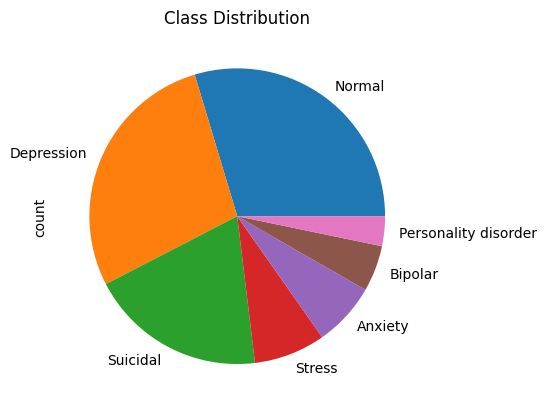

In [ ]:
df_combined["label"].value_counts().plot(kind="pie", title="Class Distribution")    # Class distribution visualization

Notice how Stress becomes larger than both Anxiety and Bipolar.

Personality disorder nearly doubles in size.

### **Data Augmented Tuned BERT Modeling**

In [ ]:
# Conduct train_test_split new dataset "df_combined"
X = df_combined['text']
y = df_combined['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Redefine evaluation metrics
def compute_metrics(y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    eval_metrics = {
        "macro_f1": macro_f1,
        "accuracy": acc,
        "confusion_matrix": cm,
        "classification_report": classification_report(y_true, y_pred, digits=4)
    }

    return eval_metrics

In [ ]:
# Consistent Hyperparameters
epochs = 2
lr = 0.00005
batch_size = 32
max_len = 256

train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = len(df_combined['label'].unique()), output_attentions = False, output_hidden_states = False,)
model.to(device)
optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

# Evaluation
metrics = evaluate(model, test_dataloader, device)
print("Macro F1 Score:", metrics["macro_f1"])
print("Accuracy:", metrics["accuracy"])
print("Confusion Matrix:\n", metrics["confusion_matrix"])
print("Classification Report:\n", metrics["classification_report"])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 ========
  Step 300/1379 - Loss: 0.4150
  Step 600/1379 - Loss: 0.6601
  Step 900/1379 - Loss: 0.4237
  Step 1200/1379 - Loss: 0.2505
  Step 1379/1379 - Loss: 0.1723
  Average training loss: 0.5505

======== Epoch 2 ========
  Step 300/1379 - Loss: 0.3081
  Step 600/1379 - Loss: 0.2797
  Step 900/1379 - Loss: 0.4390
  Step 1200/1379 - Loss: 0.4347
  Step 1379/1379 - Loss: 0.0098
  Average training loss: 0.3247
Macro F1 Score: 0.8162105235151689
Accuracy: 0.843265306122449
Confusion Matrix:
 [[ 696   18   18   13    4   17    2]
 [  17  490   21    3    9   14    1]
 [  17   32 2371   39   16   19  587]
 [   6    5   27 3148    1   62   20]
 [  10    5   16    1  174  153    0]
 [  20    7   14   38    6  773    4]
 [   1    1  449   31    0    4 1645]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9074    0.9062    0.9068       768
           1     0.8781    0.8829    0.8805       555
           2     0.8131    0.769

**Macro F1 Score: 81.621%**

**Accuracy: 84.327%**

Both Macro F1 Score and Accuracy have dropped. Right off the bat we can notice that F1 score for class 4 (personality disorder) dropped over 17% in F1 Score primarlily due to a drop in recall. This most likely has to do with augmenting personality disorder data.

Looking at our confusion matrix, Depression and Suicidal still seem to get mixed up.

On the other hand, the metrics for Stress seem to have increased which is a good sign.

Below I will rerun the same configurations only this time I will not augment the Personality Disorder data.

### **Data Augmented Tuned BERT Modeling - V2**

In [ ]:
# Construct a new dataframe with our original and augmented data
df_combined = pd.concat([df, aug_stress], ignore_index=True)
# Sort by label
df_combined = df_combined.sort_values(by='label').reset_index(drop=True)

<Axes: title={'center': 'Class Distribution'}, ylabel='count'>

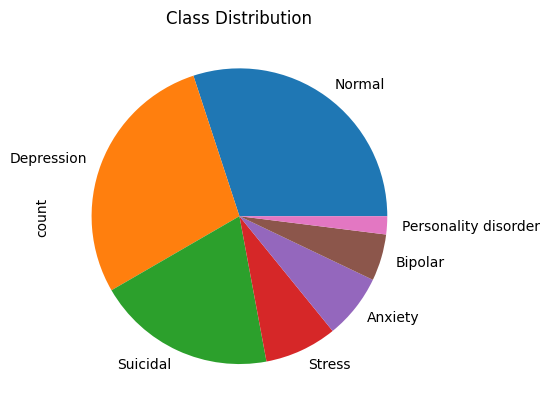

In [ ]:
df_combined["label"].value_counts().plot(kind="pie", title="Class Distribution")    # Class distribution visualization

In [ ]:
# Train_test_split on new dataset "df_combined"
X = df_combined['text']
y = df_combined['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Consistent Hyperparameters
epochs = 2
lr = 0.00005
batch_size = 32
max_len = 256

train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = len(df_combined['label'].unique()), output_attentions = False, output_hidden_states = False,)
model.to(device)
optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

# Evaluation
metrics = evaluate(model, test_dataloader, device)
print("Macro F1 Score:", metrics["macro_f1"])
print("Accuracy:", metrics["accuracy"])
print("Confusion Matrix:\n", metrics["confusion_matrix"])
print("Classification Report:\n", metrics["classification_report"])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 ========
  Step 300/1361 - Loss: 0.4934
  Step 600/1361 - Loss: 0.6381
  Step 900/1361 - Loss: 0.4110
  Step 1200/1361 - Loss: 0.3329
  Step 1361/1361 - Loss: 0.5771
  Average training loss: 0.5303

======== Epoch 2 ========
  Step 300/1361 - Loss: 0.0809
  Step 600/1361 - Loss: 0.2873
  Step 900/1361 - Loss: 0.2347
  Step 1200/1361 - Loss: 0.2066
  Step 1361/1361 - Loss: 0.1039
  Average training loss: 0.3001
Macro F1 Score: 0.8541485465271716
Accuracy: 0.8559875011487915
Confusion Matrix:
 [[ 695   17   17   11    8   17    3]
 [  17  482   27    4    7   17    2]
 [  10   24 2398   35    2    8  604]
 [  16    1   28 3148    4   50   22]
 [   5    5   23    8  165    9    0]
 [  27    6   17   54    9  748    1]
 [   2    0  420   30    0    0 1678]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9003    0.9049    0.9026       768
           1     0.9009    0.8669    0.8836       556
           2     0.8184    0.77

## **Summary of Data Augmented Tuned BERT-base Results:**

###**Hyperparameters**
Learning Rate: 0.00005

Batch Size: 32

Maximum Sequence Length: 256

###**Metrics**
Accuracy: 85.599%

Macro F1 Score: 85.415%

###**Analysis**
So far, this model has yielded the best results.
Augmenting only the Stress class proved to be beneficial, increasing the macro F1 score of Stress by 8.5%.

Personality Disorder F1 score surpassed its score in both the Tuned model and V1 of the data augmented model.

Additionally, most classes saw a slight increase in F1, leading to a higher Macro F1 score.


# **Stage 3: Advanced Architecture**

### **Hypotheses for MentalBERT Advanced Architecture**
**Hypothesis 3.1:**
MentalBERT's advanced and domain-specific architecture will outperform the “BERT-base baseline” model, primarily in minority class detection.

**Hypothesis 3.2:**
The data augmented MentalBERT model will outperform the baseline MentalBERT model when only class 5 ("Stress") is augmented.

## **MentalBERT (Baseline and Augmented):**
MentalBERT is a domain-specific BERT model pre-trained on mental health–related texts, such as Reddit posts from mental health forums. Unlike the original BERT, which is trained on general-purpose text like Wikipedia and BooksCorpus, MentalBERT is fine-tuned to better understand the linguistic patterns, emotional cues, and informal expressions common in mental health discussions.

MentalBERT's domain specific pretraining makes it particularly effective for this research project.

In [ ]:
# Use of MentalBERT requires login access token
from huggingface_hub import login
login()

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Set Model to MentalBERT
# Using AutoTokenizer and AutoModelForSequenceClassification because this is not the standard BERT architecture. These allow us to enter any BERT model name and get the correct architecture.
tokenizer = AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "mental/mental-bert-base-uncased",
    num_labels = len(df['label'].unique()),
    output_attentions = False,
    output_hidden_states = False,
)
model.to(device)

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### **MentalBERT Baseline**

In [ ]:
# For research purposes run train_test_split on the standard data set (w/o augmentation) for MentalBERT ("Baseline Modeling:")

# Optimal Hyperparameters
epochs = 2
lr = 0.00005
batch_size = 32
max_len = 256

train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

    # Evaluation per epoch
    metrics = evaluate(model, test_dataloader, device)
    print("Macro F1 Score:", metrics["macro_f1"])
    print("Accuracy:", metrics["accuracy"])
    print("Confusion Matrix:\n", metrics["confusion_matrix"])
    print("Classification Report:\n", metrics["classification_report"])


======== Epoch 1 ========
  Step 300/1317 - Loss: 0.6088
  Step 600/1317 - Loss: 0.6737
  Step 900/1317 - Loss: 0.5699
  Step 1200/1317 - Loss: 0.4092
  Step 1317/1317 - Loss: 0.2678
  Average training loss: 0.4925
Macro F1 Score: 0.8215089562369987
Accuracy: 0.8398975040334061
Confusion Matrix:
 [[ 666   21   21   10   13   36    1]
 [  16  477   31    8    6   18    0]
 [   9   20 2512   50   14   22  454]
 [  23    4   14 3164    1   48   15]
 [  10    6   22    9  155   12    1]
 [  25    0   18   62    6  404    2]
 [   0    2  613   42    0    2 1472]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8892    0.8672    0.8780       768
           1     0.9000    0.8579    0.8785       556
           2     0.7775    0.8153    0.7959      3081
           3     0.9459    0.9679    0.9568      3269
           4     0.7949    0.7209    0.7561       215
           5     0.7454    0.7814    0.7630       517
           6     0.7568    0.69

### **Summary of MentalBERT Baseline**
Performance is lower than expected, but this model may be more susceptible to hyperparameter tuning. Metrics are close to that of the Tuned BERT-base model. Macro F1 score falls below evaluation accuracy suggesting a harsher impact on performance due to class imbalance.

MentalBERT performs better when training for 2 epochs as opposed to 1, especially on some of the smaller classes. Better to stick with 2 epochs. Like with BERT-base, 2 epochs maintains a good balance between performance and runtime.

Below, I will run the MentalBERT model on the **augmented + original** dataset to observe augmentation impact on MentalBERT.

### **Data Augmentation MentalBERT**

In [ ]:
# Reaugment "Stress" if needed and conduct train_test_split on "df_combined" ("Data Augmented Tuned BERT-base Model:")

# Optimal Hyperparameters
epochs = 2
lr = 0.00005
batch_size = 32
max_len = 256

train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

    # Evaluation per epoch
    metrics = evaluate(model, test_dataloader, device)
    print("Macro F1 Score:", metrics["macro_f1"])
    print("Accuracy:", metrics["accuracy"])
    print("Confusion Matrix:\n", metrics["confusion_matrix"])
    print("Classification Report:\n", metrics["classification_report"])


======== Epoch 1 ========
  Step 300/1361 - Loss: 0.6716
  Step 600/1361 - Loss: 0.5847
  Step 900/1361 - Loss: 0.5379
  Step 1200/1361 - Loss: 0.3982
  Step 1361/1361 - Loss: 0.3906
  Average training loss: 0.5269
Macro F1 Score: 0.8346972480745878
Accuracy: 0.8431210366694237
Confusion Matrix:
 [[ 666   31   23   15    9   20    4]
 [  16  469   45    7    8    8    3]
 [   5   16 2191   50   11   13  795]
 [  14    4   20 3174    0   50    7]
 [   4   13   25    6  155   12    0]
 [  24   14   22   59   10  729    4]
 [   2    0  297   41    0    0 1790]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9111    0.8672    0.8886       768
           1     0.8574    0.8435    0.8504       556
           2     0.8353    0.7111    0.7682      3081
           3     0.9469    0.9709    0.9588      3269
           4     0.8031    0.7209    0.7598       215
           5     0.8762    0.8457    0.8607       862
           6     0.6877    0.84

## **Summary of Data Augmented MentalBERT Results**

### **Hyperparameters**
Learning Rate: 0.00005

Batch Size: 32

Maximum Sequence Length: 256

### **Metrics**
Accuracy: 85.488%

Macro F1 Score: 85.111%

### **Analysis**
Results are very similar, but slightly inferior, to Augmented BERT-base V2

Augmenting regardless of model type shows a strong positive correlation on "Stress" F1 Score.

Although nearly opposites in class size, both Depression and Personality disorder have a similar Macro F1 Score. (Mainly due to mix-up between "Depression" and "Suicidal")

## **Grid Search MentalBERT**
Augmented Data MentalBERT
Test max_len=256, and...

batch_sizes = [16, 32, 64]

learning_rates = [5e-5, 1e-4]

In [ ]:
def grid_search_mentalBERT(batch_size):
    """
    Perform a grid search over two fixed learning rates [0.0001, 0.00005]
    with a fixed maximum sequence length of 256 tokens using the MentalBERT model,
    for the specified batch size.

    Args:
        batch_size {int}: Batch size for training.

    Returns:
        list of dict: List containing evaluation metric dictionaries for each combo.
                      Each dictionary includes metrics such as macro F1 score, accuracy,
                      and the corresponding batch size and learning rate used.
    """
    max_len = 256
    epochs = 2
    learning_rates = [1e-4, 5e-5]
    results = []

    for lr in learning_rates:
        print(f"\nTraining with batch size {batch_size} and learning rate {lr}")

        train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
        model = BertForSequenceClassification.from_pretrained("mental/mental-bert-base-uncased", num_labels=len(df_combined['label'].unique()), output_attentions=False, output_hidden_states=False)
        model.to(device)
        optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
        total_steps = len(train_dataloader) * epochs
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

        for epoch in range(epochs):
            print(f"Epoch {epoch+1}")
            avg_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)
            print(f"Avg training loss: {avg_loss:.4f}")

        metrics = evaluate(model, test_dataloader, device)
        print("  Macro F1 Score:", metrics["macro_f1"])
        print("  Accuracy:", metrics["accuracy"])

In [ ]:
grid_search_mentalBERT(32)


Training with batch size 32 and learning rate 0.0001


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1
  Step 300/1361 - Loss: 0.7117
  Step 600/1361 - Loss: 0.5309
  Step 900/1361 - Loss: 0.5062
  Step 1200/1361 - Loss: 0.4802
  Step 1361/1361 - Loss: 0.0237
  Average training loss: 0.5008
Avg training loss: 0.5008
Epoch 2
  Step 300/1361 - Loss: 0.3726
  Step 600/1361 - Loss: 0.3411
  Step 900/1361 - Loss: 0.2057
  Step 1200/1361 - Loss: 0.3761
  Step 1361/1361 - Loss: 0.1563
  Average training loss: 0.2816
Avg training loss: 0.2816
Macro F1: 0.8626 | Accuracy: 0.8602

Training with batch size 32 and learning rate 5e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1


KeyboardInterrupt: 

In [ ]:
grid_search_mentalBERT(16)


Training with batch size 16 and learning rate 0.0001


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1
  Step 300/2721 - Loss: 0.5029
  Step 600/2721 - Loss: 0.3345
  Step 900/2721 - Loss: 0.5254
  Step 1200/2721 - Loss: 0.5808
  Step 1500/2721 - Loss: 0.4752
  Step 1800/2721 - Loss: 0.4351
  Step 2100/2721 - Loss: 0.8802
  Step 2400/2721 - Loss: 0.6797
  Step 2700/2721 - Loss: 0.5466
  Step 2721/2721 - Loss: 0.1681
  Average training loss: 0.5410
Avg training loss: 0.5410
Epoch 2
  Step 300/2721 - Loss: 0.3034
  Step 600/2721 - Loss: 0.2722
  Step 900/2721 - Loss: 0.1877
  Step 1200/2721 - Loss: 0.2490
  Step 1500/2721 - Loss: 0.5444
  Step 1800/2721 - Loss: 0.0939
  Step 2100/2721 - Loss: 0.1129
  Step 2400/2721 - Loss: 0.7368
  Step 2700/2721 - Loss: 0.1534
  Step 2721/2721 - Loss: 0.0447
  Average training loss: 0.3191
Avg training loss: 0.3191
Macro F1: 0.85437 | Accuracy: 0.85433

Training with batch size 16 and learning rate 5e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1
  Step 300/2721 - Loss: 0.4331
  Step 600/2721 - Loss: 0.5506
  Step 900/2721 - Loss: 0.2285
  Step 1200/2721 - Loss: 0.3476
  Step 1500/2721 - Loss: 0.5411
  Step 1800/2721 - Loss: 0.7056
  Step 2100/2721 - Loss: 0.4534
  Step 2400/2721 - Loss: 0.7084
  Step 2700/2721 - Loss: 0.3455
  Step 2721/2721 - Loss: 0.4366
  Average training loss: 0.4902
Avg training loss: 0.4902
Epoch 2
  Step 300/2721 - Loss: 0.3885
  Step 600/2721 - Loss: 0.0382
  Step 900/2721 - Loss: 0.2414
  Step 1200/2721 - Loss: 0.7154
  Step 1500/2721 - Loss: 0.4322
  Step 1800/2721 - Loss: 0.6218
  Step 2100/2721 - Loss: 0.3127
  Step 2400/2721 - Loss: 0.1796
  Step 2700/2721 - Loss: 0.0221
  Step 2721/2721 - Loss: 0.0029
  Average training loss: 0.2775
Avg training loss: 0.2775
Macro F1: 0.86202 | Accuracy: 0.86159


[{'macro_f1': 0.8543733620509917,
  'accuracy': 0.8543332414300157,
  'confusion_matrix': array([[ 690,   22,   19,   12,    6,   18,    1],
         [  18,  491,   24,    4,    5,   12,    2],
         [  11,   21, 2417,   37,    6,    4,  585],
         [  17,    2,   20, 3142,    1,   77,   10],
         [   4,    9,   19,    5,  171,    7,    0],
         [  25,   15,   12,   37,   11,  761,    1],
         [   3,    1,  470,   32,    0,    0, 1624]]),
  'classification_report': '              precision    recall  f1-score   support\n\n           0     0.8984    0.8984    0.8984       768\n           1     0.8752    0.8831    0.8791       556\n           2     0.8108    0.7845    0.7974      3081\n           3     0.9612    0.9612    0.9612      3269\n           4     0.8550    0.7953    0.8241       215\n           5     0.8658    0.8828    0.8742       862\n           6     0.7305    0.7624    0.7462      2130\n\n    accuracy                         0.8543     10881\n   macro avg

In [ ]:
grid_search_mentalBERT(64)


Training with batch size 64 and learning rate 0.0001


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


  Step 300/681 - Loss: 0.4138
  Step 600/681 - Loss: 0.3369
  Step 681/681 - Loss: 0.3234
  Average training loss: 0.4924
Avg training loss: 0.4924
Epoch 2
  Step 300/681 - Loss: 0.2267
  Step 600/681 - Loss: 0.2856
  Step 681/681 - Loss: 0.4145
  Average training loss: 0.2756
Avg training loss: 0.2756
  Macro F1 Score: 0.8625264149921367
  Accuracy: 0.8618693134822167

Training with batch size 64 and learning rate 5e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Epoch 1
  Step 300/681 - Loss: 0.5988
  Step 600/681 - Loss: 0.3473
  Step 681/681 - Loss: 0.7779
  Average training loss: 0.4932
Avg training loss: 0.4932
Epoch 2
  Step 300/681 - Loss: 0.2750
  Step 600/681 - Loss: 0.1820
  Step 681/681 - Loss: 0.2083
  Average training loss: 0.2857
Avg training loss: 0.2857
  Macro F1 Score: 0.860406618981085
  Accuracy: 0.8610421836228288


## **Summary of Tuned Data Augmented MentalBERT Results**


### **Optimal Hyperparameters**
max_len = 256

batch_size = 64

lr = 0.0001

### **Metrics**
Macro F1 Score: 86.346%

Accuracy: 86.123%

### **Analysis**
Class 5 ("Stress") was augmented using synonym replacement.

The architecture used was that of the MentalBERT uncased model: a BERT based transformer architecture pretrained on social media text data.

A grid search was conducted in batches on a set of 6 possible hyperparameter combinations and the optimal combination is as shown above.

Hyperparameter tuning on Mental BERT shows an evidently positive effect on performance culminating in a higher accuracy and macro-averaged F1 score than any other model in this project.




# **Final Model**

In [ ]:
# Optimal Hyperparameters
epochs = 2
lr = 0.0001
batch_size = 64
max_len = 256


model = BertForSequenceClassification.from_pretrained("mental/mental-bert-base-uncased", num_labels=len(df_combined['label'].unique()), output_attentions=False, output_hidden_states=False)
model.to(device)
train_dataloader, test_dataloader = create_dataloaders(X_train, y_train, X_test, y_test, tokenizer, max_len, batch_size)
optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                            num_training_steps=total_steps)

# Training
for epoch in range(epochs):
    print(f"\n======== Epoch {epoch+1} ========")
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

# Evaluation
metrics = evaluate(model, test_dataloader, device)
print("Macro F1 Score:", metrics["macro_f1"])
print("Accuracy:", metrics["accuracy"])
print("Confusion Matrix:\n", metrics["confusion_matrix"])
print("Classification Report:\n", metrics["classification_report"])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 ========


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


  Step 300/681 - Loss: 0.4720
  Step 600/681 - Loss: 0.2987
  Step 681/681 - Loss: 0.1792
  Average training loss: 0.4899

======== Epoch 2 ========
  Step 300/681 - Loss: 0.3014
  Step 600/681 - Loss: 0.2833
  Step 681/681 - Loss: 0.2061
  Average training loss: 0.2746
Macro F1 Score: 0.8634591847700998
Accuracy: 0.8612259902582483
Confusion Matrix:
 [[ 701   12   18    8    7   20    2]
 [  17  488   27    6    4   13    1]
 [  14   20 2459   31    6    5  546]
 [  13    2   17 3164    4   57   12]
 [   5    7   19    6  174    4    0]
 [  26    7   18   41    5  763    2]
 [   3    1  472   31    0    1 1622]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8999    0.9128    0.9063       768
           1     0.9088    0.8777    0.8930       556
           2     0.8116    0.7981    0.8048      3081
           3     0.9626    0.9679    0.9652      3269
           4     0.8700    0.8093    0.8386       215
           5     0.8841    0.8

## **Saving Final Model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/BERT_Mental_Health_Model/'

Mounted at /content/drive


In [ ]:
# Save Model
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

('/content/drive/MyDrive/BERT_Mental_Health_Model/tokenizer_config.json',
 '/content/drive/MyDrive/BERT_Mental_Health_Model/special_tokens_map.json',
 '/content/drive/MyDrive/BERT_Mental_Health_Model/vocab.txt',
 '/content/drive/MyDrive/BERT_Mental_Health_Model/added_tokens.json',
 '/content/drive/MyDrive/BERT_Mental_Health_Model/tokenizer.json')

In [ ]:
# To load model after saving, run the following code (in this or another notebook)
"""
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification

load_path = '/content/drive/MyDrive/BERT_Mental_Health_Model/'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(load_path)
model.to(device)
tokenizer = AutoTokenizer.from_pretrained(load_path)
model.eval()
"""

'\nfrom google.colab import drive\nfrom transformers import AutoTokenizer, AutoModelForSequenceClassification\n\nload_path = \'/content/drive/MyDrive/BERT_Mental_Health_Model/\'\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nmodel = AutoModelForSequenceClassification.from_pretrained(load_path)\nmodel.to(device)\ntokenizer = AutoTokenizer.from_pretrained(load_path)\nmodel.eval()\n'